# **SARIMA Modeling & Forecasting**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [7]:
# --- 1. Load Data ---
dataset = sm.datasets.get_rdataset("AirPassengers")
df = dataset.data
df['time'] = pd.date_range(start='1949-01-01', periods=len(df), freq='MS')
df.set_index('time', inplace=True)
ts_data = df['value']

In [8]:
# --- 3. Fit the SARIMA Model ---
model = SARIMAX(ts_data, 
                order=(0, 1, 1),              # (p, d, q)
                seasonal_order=(0, 1, 1, 12), # (P, D, Q, m)
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3175      0.073     -4.342      0.000      -0.461      -0.174
ma.S.L12      -0.1123      0.097     -1.158      0.247      -0.302       0.078
sigma2       145.3969     18.013      8.072      0.000     110.093     180.701


/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/Caskroom/miniconda/base/envs/academic/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [9]:
# --- 4. Forecast the Next 12 Periods ---
forecast_steps = 12
forecast_obj = results.get_forecast(steps=forecast_steps)
forecast_vals = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

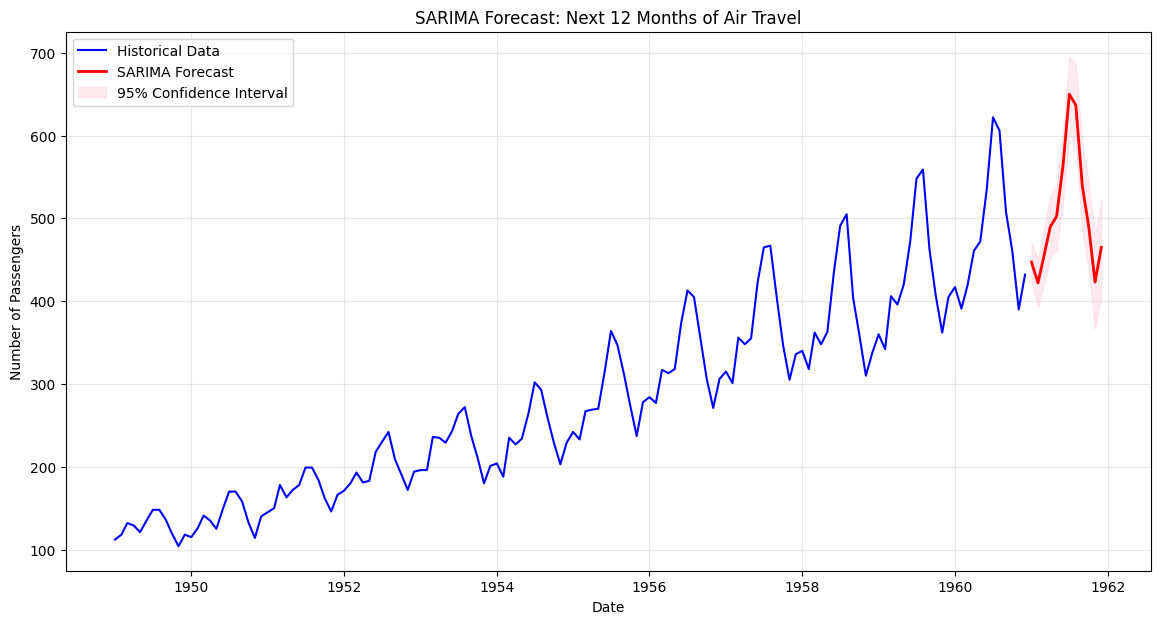

In [10]:
# --- 5. Plotting ---
plt.figure(figsize=(14, 7))

# Plot historical data
plt.plot(ts_data.index, ts_data, label='Historical Data', color='blue')

# Plot Forecast
plt.plot(forecast_vals.index, forecast_vals, label='SARIMA Forecast', color='red', linewidth=2)

# Plot Confidence Intervals (The shaded area)
plt.fill_between(forecast_vals.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('SARIMA Forecast: Next 12 Months of Air Travel')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SARIMA Analysis on the AirPassengers Dataset  
### (Using Python SARIMA(0,1,1)x(0,1,1,12))

Below is the interpretation of results for the SARIMA model applied to the **AirPassengers** dataset. This dataset exhibits strong **trend** and **seasonality**, making SARIMA necessary instead of simple ARIMA.

---

## 1. **Parameter Selection (P, D, Q, m)**

### **Season Length (m = 12)**
- The dataset is **monthly**.
- The pattern repeats **every 12 months** (strong annual cycle).

### **Seasonal Differencing (D = 1)**
- Seasonal amplitudes increase over time.
- Applying **seasonal differencing** (subtracting value from same month of previous year) stabilizes the seasonal pattern.

### **Non-Seasonal Differencing (d = 1)**
- The data has a clear upward trend; differencing once removes this trend.

### **Seasonal Parameters (P, Q)**
- ACF at **lag 12** is significant and negative → indicates a **Seasonal MA component**.
- The classic **Airline Model** uses:
  - Seasonal order: **(P, D, Q, m) = (0, 1, 1, 12)**

### **Non-Seasonal Parameters (p, q)**
- Based on airline model standards:
  - Non-seasonal order: **(0, 1, 1)**

Thus, the final model:
\[
\text{SARIMA}(0,1,1) \times (0,1,1)_{12}
\]

---

## 2. **Interpretation of the Forecast Plot**

### **Pattern Continuity**
- The **red forecast line** successfully reproduces the repeating seasonal pattern:
  - Peaks during summer.
  - Dips during winter.
- This behavior would not be captured by a simple ARIMA model.

### **Trend Continuity**
- The forecast maintains the historical **upward trend**, matching the increasing air travel demand seen in earlier years.

### **Uncertainty Visualization**
- The **pink shaded band** shows the **95% confidence interval**.
- It naturally **widens** over time:
  - Short-term predictions: more accurate  
  - Long-term predictions: less certain

This widening reflects increasing uncertainty in monthly passenger estimates as we move further into the future.

---

## 3. **Conclusion**

The SARIMA model:

- Correctly identifies and models **trend**  
- Accurately captures **seasonality**  
- Produces realistic forecasts that mirror the historical travel patterns

A simple ARIMA model would treat seasonal dips as random shocks, whereas SARIMA appropriately treats them as **systematic, predictable yearly patterns**.

Thus, **SARIMA(0,1,1)x(0,1,1,12)** is the most suitable model for the AirPassengers dataset.

---